# 4 · Probability, uncertainty and inference

**Prerequisite:** Steps 1 and 3. **Destination:** Understand what the book means by a distribution, likelihood, posterior, distribution distance, MCMC and variational inference.

The key change is that we stop treating every unknown as one perfectly known number. We describe alternatives and how plausible they are under an explicit model.

## 1. Probability and random variables

A probability lies between 0 and 1. Mutually exclusive exhaustive outcomes have probabilities summing to 1. A **random variable** assigns a numerical value to an uncertain outcome. For a simplified component-state variable, $Y=1$ could mean failed and $Y=0$ working.

A **distribution** tells us how probability is allocated. A Bernoulli distribution with parameter $p$ puts probability $p$ on 1 and $1-p$ on 0. “Sample from it” means generate an outcome according to those probabilities; it does not mean always return the more likely outcome.

The expectation is a probability-weighted average, $E[Y]=\sum_y yP(Y=y)$. For a Bernoulli variable it is $p$. The variance $E[(Y-E[Y])^2]$ measures spread around that average; for Bernoulli it is $p(1-p)$.

**Conditional probability** means probability after restricting attention to a condition. $P(A\mid B)$ reads “probability of A given B.” It need not equal $P(B\mid A)$. Independence would mean $P(A\mid B)=P(A)$ when conditioning is defined; independence is an assumption to justify, not a consequence of having two column names.

### Checkpoint 1

A random variable takes 0 with probability 0.7 and 10 with probability 0.3. Calculate its expectation. Must an individual sample equal that expectation?

<details><summary>Worked answer</summary>

The expectation is $0\times0.7+10\times0.3=3$. Each individual sample is either 0 or 10, never 3. An expectation summarizes a distribution; it need not be one of its possible outcomes.

</details>

## 2. Continuous quantities have densities

For a continuous measurement, probability comes from **area under a density**, not the density's value at one point. The notation $\int_a^b p(x)\,dx$ means adding infinitely thin contributions of area between $a$ and $b$. The full area under a probability density is 1. A density can be higher than 1 because height is not probability.

A continuous variable has zero probability of equalling any one exact real number under an ordinary density model; finite intervals can have nonzero probability. Measurements have finite precision, so reported values correspond to small intervals in such a model.

A Gaussian (normal) density is

$$p(x)=\frac{1}{\sigma\sqrt{2\pi}}\exp\!\left[-\frac{(x-\mu)^2}{2\sigma^2}\right].$$

The mean $\mu$ sets the centre and standard deviation $\sigma>0$ sets the spread. Squared distance from the centre reduces density exponentially. A narrower Gaussian is taller because the total area must stay 1. If $x$ is in mm, the density is in inverse mm.

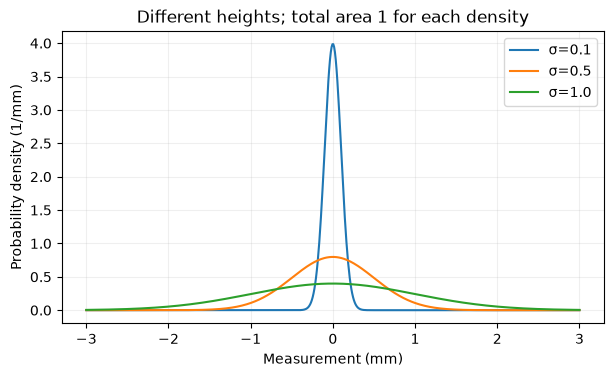

For σ=0.1, density at zero: 3.989422804014327
For σ=0.1, probability between -0.1 and 0.1: 0.6826894921370859


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, beta
from ipywidgets import interact, IntSlider

grid = np.linspace(-3, 3, 600)
fig, ax = plt.subplots(figsize=(7, 3.8))
for standard_deviation in [0.1, 0.5, 1.0]:
    ax.plot(grid, norm.pdf(grid, loc=0, scale=standard_deviation), label=f"σ={standard_deviation}")
ax.set(xlabel="Measurement (mm)", ylabel="Probability density (1/mm)", title="Different heights; total area 1 for each density")
ax.legend(); ax.grid(alpha=0.2); plt.show()
print("For σ=0.1, density at zero:", norm.pdf(0, scale=0.1))
print("For σ=0.1, probability between -0.1 and 0.1:", norm.cdf(0.1, scale=0.1)-norm.cdf(-0.1, scale=0.1))

An **expectation** for a continuous variable replaces the sum with an integral: $E[f(X)]=\int f(x)p(x)dx$. Monte Carlo approximates this by averaging $f(x)$ over sampled values. More samples usually improve accuracy, but dependence between samples can reduce the effective information gained.

## 3. Bayes: update a belief using evidence

Bayes' rule is

$$P(H\mid D)=\frac{P(D\mid H)P(H)}{P(D)}.$$

Here $H$ is a hypothesis and $D$ the observed data. The **prior** $P(H)$ describes uncertainty before these data. The **likelihood** $P(D\mid H)$ describes how compatible the observed data are with a hypothesis. The **posterior** is the updated distribution. The **evidence** $P(D)$ normalizes across all hypotheses.

Consider a fictional alarm with these stipulated probabilities: 10% of components are faulty; the alarm fires on 80% of faulty components and on 20% of working components. Out of 1,000 expected cases, 100 are faulty and 80 of those produce an alarm. Of 900 working components, 180 produce an alarm. An alarm is therefore associated with a fault in $80/(80+180)\approx30.8\%$ of these modeled cases.

This is not 80%: $P(\text{alarm}\mid\text{fault})$ and $P(\text{fault}\mid\text{alarm})$ ask different questions. The prior frequency matters.

### Checkpoint 2

In that fictional example, change the prior fault probability to 0.5 while keeping the two alarm probabilities unchanged. What is the posterior fault probability after an alarm?

<details><summary>Worked answer</summary>

$P(\text{fault}\mid\text{alarm})=(0.8\times0.5)/(0.8\times0.5+0.2\times0.5)=0.8$. The evidence is $0.5$, and the posterior is 80%. The same alarm behaviour gives a different posterior when the prior changes.

</details>

## 4. Updating uncertainty about a parameter

Suppose repeated binary experiments have unknown success probability $p$. A **Beta distribution** is a distribution over possible values of $p$ between 0 and 1. Start with a Beta(2,2) prior. Observing $h$ successes and $t$ failures, assuming independent Bernoulli trials with a fixed $p$, gives a Beta$(2+h,2+t)$ posterior.

Its mean is $(2+h)/(4+h+t)$. Seven successes and three failures give Beta(9,5), with mean $9/14\approx0.643$. It differs from the observed fraction 0.7 because the prior also contributes information. With many more observations, this fixed prior has less relative influence.

In [2]:
def update_probability(successes=7, failures=3):
    p = np.linspace(0.001, 0.999, 400)
    posterior_a, posterior_b = 2 + successes, 2 + failures
    fig, ax = plt.subplots(figsize=(7, 3.8))
    ax.plot(p, beta.pdf(p, 2, 2), "--", label="Prior: Beta(2,2)")
    ax.plot(p, beta.pdf(p, posterior_a, posterior_b), label="Posterior")
    ax.set(xlabel="Unknown success probability p", ylabel="Density over p",
           title=f"{successes} successes, {failures} failures · posterior mean={posterior_a/(posterior_a+posterior_b):.3f}")
    ax.legend(); ax.grid(alpha=0.2); plt.show()

interact(update_probability,
         successes=IntSlider(value=7, min=0, max=50, continuous_update=False),
         failures=IntSlider(value=3, min=0, max=50, continuous_update=False));

interactive(children=(IntSlider(value=7, continuous_update=False, description='successes', max=50), IntSlider(…

Compare 7/3 and 35/15. Both have 70% observed success. Explain why their posterior distributions differ in spread and why their means need not be identical.

## 5. Likelihood connects probability to loss functions

For independent observations, a likelihood is a product of per-observation probabilities or densities. **Maximum likelihood estimation (MLE)** chooses the parameter values that maximize this product. Taking logs converts the product to a sum, and minimizing the **negative** log-likelihood reverses maximization into minimization.

If $y_i=f_w(x_i)+\epsilon_i$ and independent noise $\epsilon_i$ is Gaussian with known constant variance $\sigma^2$, then

$$-\log p(D\mid w)=\text{constant}+\frac{1}{2\sigma^2}\sum_i(y_i-f_w(x_i))^2.$$

That is why squared residuals arise naturally from a particular noise model. It does not mean all datasets must use squared loss. A different observation model yields a different loss.

**Maximum a posteriori estimation (MAP)** maximizes the posterior density. With an independent zero-mean Gaussian prior on each penalized weight of variance $\tau^2$, the negative log-prior contributes $\sum_jw_j^2/(2\tau^2)$. Thus MAP connects a squared-L2 penalty to a probabilistic assumption. A point estimate such as MAP is not the same as representing the whole posterior distribution.

### Checkpoint 3

What is the difference between choosing the single most plausible slope and retaining a distribution over plausible slopes? Why can two datasets with similar best-fit slopes have different uncertainty?

<details><summary>Worked answer</summary>

A point estimate identifies one slope; a posterior describes alternatives and their relative plausibility under the model. A small noisy dataset can allow many plausible slopes, while a large informative dataset can constrain the slope tightly, even when their point estimates are similar.

</details>

## 6. Parameter uncertainty versus future measurement noise

We return to a spring model $y=wx+\epsilon$, fixing the intercept at zero for this demonstration. Assume $w\sim N(0,2^2)$ and observation noise $\epsilon\sim N(0,0.25^2)$. For this simple model the posterior over $w$ is Gaussian and can be calculated exactly.

If its mean and variance are $\mu_w$ and $s_w^2$, then a new measurement at input $x$ has predictive mean $x\mu_w$ and variance $x^2s_w^2+\sigma^2$. The first term is uncertainty about the slope; the second is new observation noise. Collecting more informative data can reduce the first, but does not remove the assumed noise in a new measurement.

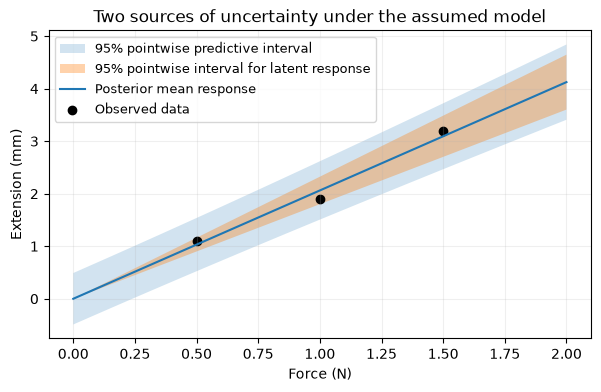

Posterior slope mean: 2.0622222222222226 standard deviation: 0.13333333333333333


In [3]:
x_obs = np.array([0.5, 1.0, 1.5])
y_obs = np.array([1.1, 1.9, 3.2])
noise_sd = 0.25
prior_sd = 2.0
posterior_variance = 1 / (1 / prior_sd**2 + np.sum(x_obs**2) / noise_sd**2)
posterior_mean = posterior_variance * np.sum(x_obs*y_obs) / noise_sd**2
xs = np.linspace(0, 2, 120)
mean_prediction = xs * posterior_mean
function_sd = np.abs(xs) * np.sqrt(posterior_variance)
predictive_sd = np.sqrt(function_sd**2 + noise_sd**2)
fig, ax = plt.subplots(figsize=(7, 4))
ax.fill_between(xs, mean_prediction-1.96*predictive_sd, mean_prediction+1.96*predictive_sd,
                alpha=0.2, label="95% pointwise predictive interval")
ax.fill_between(xs, mean_prediction-1.96*function_sd, mean_prediction+1.96*function_sd,
                alpha=0.35, label="95% pointwise interval for latent response")
ax.plot(xs, mean_prediction, label="Posterior mean response")
ax.scatter(x_obs, y_obs, color="black", label="Observed data")
ax.set(xlabel="Force (N)", ylabel="Extension (mm)", title="Two sources of uncertainty under the assumed model")
ax.legend(fontsize=9); ax.grid(alpha=0.2); plt.show()
print("Posterior slope mean:", posterior_mean, "standard deviation:", np.sqrt(posterior_variance))

These are model-based, pointwise intervals, not a guarantee that an entire future curve is covered or that the assumed spring law is correct. They omit uncertainty about the chosen model form and known noise scale.

## 7. Compare entire distributions

A prediction error compares an output with a target. A **distribution discrepancy** compares patterns of probability mass. The course uses these to train generative models and compare approximations.

For discrete probabilities with compatible support, the KL divergence is

$$D_{KL}(P\|Q)=\sum_i p_i\log\frac{p_i}{q_i}.$$

It is nonnegative but generally asymmetric: swapping $P$ and $Q$ changes the answer. If $p_i>0$ where $q_i=0$, this direction of KL is infinite. It is not an ordinary symmetric metric.

The Jensen–Shannon divergence compares each distribution to their mixture; using natural logarithms it lies between 0 and $\log2$. MMD compares expected feature representations, often implicitly via a kernel; its ability to distinguish distributions depends on the kernel. Optimal transport compares the cost of moving probability mass between locations. Unlike a pointwise comparison of bins, it uses a notion of distance between locations.

For example, point masses at positions 0 and 1 have a Wasserstein-1 distance of 1 in the position's units. Their KL divergences are infinite because their supports do not overlap. The two discrepancies answer different questions.

In [4]:
from scipy.stats import wasserstein_distance

p = np.array([0.75, 0.25])
q = np.array([0.5, 0.5])
kl_pq = np.sum(p * np.log(p / q))
kl_qp = np.sum(q * np.log(q / p))
print("KL(P || Q):", round(kl_pq, 4), "nats")
print("KL(Q || P):", round(kl_qp, 4), "nats")
print("Wasserstein-1 between point masses at 0 and 1:", wasserstein_distance([0], [1]))
assert kl_pq >= 0 and kl_qp >= 0

KL(P || Q): 0.1308 nats
KL(Q || P): 0.1438 nats
Wasserstein-1 between point masses at 0 and 1: 1.0


A **kernel**, in this context, is a suitable similarity function between observations, such as $k(x,z)=\exp(-\|x-z\|^2/(2\ell^2))$. It is unrelated to the Jupyter kernel that executes Python. The length scale $\ell$ controls how quickly similarity decreases with distance.

### Checkpoint 4

Why is it incomplete to say “the KL distance between P and Q is small”? Why might geometry matter when comparing two distributions of airfoil shapes?

<details><summary>Worked answer</summary>

Specify the direction $D_{KL}(P\|Q)$ or $D_{KL}(Q\|P)$; KL is not generally symmetric and is not a metric. Geometrically close shapes should often be distinguished from very different shapes, which requires a meaningful ground distance or feature representation. The choice of discrepancy expresses what differences matter.

</details>

## 8. Why approximate inference is needed

Bayes' rule can be easy to write and hard to compute. The evidence for continuous parameters is an integral over all possible parameter values. For a large neural network there may be millions of interacting unknowns. The challenge is not “Bayes stops being true”; the integrals become computationally difficult.

**Markov chain Monte Carlo (MCMC)** constructs dependent samples so that, under appropriate conditions, their long-run distribution is the desired posterior. Metropolis–Hastings proposes a move and accepts it with a suitable probability. For a symmetric proposal, the acceptance probability is $\min(1,p_{new}/p_{old})$ for an unnormalized target $p$. Common normalization constants cancel. Poor proposals, insufficient exploration, or unassessed convergence can give misleading approximations. Hamiltonian Monte Carlo uses gradients to make more informed proposals.

Here is a small discrete analogue. Adjacent states have symmetric proposal probabilities; boundary proposals can stay put. The histogram should approach the target frequencies, with finite-sample differences.

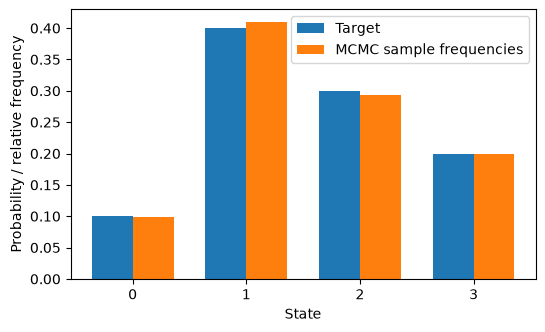

In [5]:
rng = np.random.default_rng(29)
target = np.array([0.1, 0.4, 0.3, 0.2])
state = 0
samples = []
for iteration in range(6000):
    proposal = int(np.clip(state + rng.choice([-1, 1]), 0, 3))
    if rng.random() < min(1.0, target[proposal] / target[state]):
        state = proposal
    if iteration >= 500:
        samples.append(state)
frequencies = np.bincount(samples, minlength=4) / len(samples)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(np.arange(4)-0.18, target, width=0.36, label="Target")
ax.bar(np.arange(4)+0.18, frequencies, width=0.36, label="MCMC sample frequencies")
ax.set(xlabel="State", ylabel="Probability / relative frequency", xticks=range(4))
ax.legend(); plt.show()

**Variational inference (VI)** instead chooses a tractable family $q_\phi(w)$ and optimizes its parameters to approximate the posterior. It replaces a sampling problem with an optimization problem. The chosen family may miss dependencies or modes even if the optimization is good.

For a valid $q$ with appropriate support, define

$$\mathrm{ELBO}=E_q[\log p(D,w)-\log q(w)].$$

The key identity is

$$\log p(D)=\mathrm{ELBO}+D_{KL}(q(w)\|p(w\mid D)).$$

The log evidence is constant with respect to $q$; KL is nonnegative. Thus maximizing the ELBO minimizes this KL and explains the name **evidence lower bound**. You will meet the same logic again in variational autoencoders. A **probabilistic programming language**, such as Pyro in the course, helps specify distributions and run inference; it does not remove the need to understand assumptions and diagnostics.

### Checkpoint 5

How do MCMC and VI represent a posterior approximation? Why does a high ELBO not establish that the original physical model is correct?

<details><summary>Worked answer</summary>

MCMC uses a collection of dependent samples intended to explore the target distribution. VI uses an optimized distribution from a chosen family. A good approximation to the posterior of a misspecified model can still give wrong physical conclusions. Approximation quality and model validity are separate questions.

</details>

## Ready to continue?

Explain probability versus density, prior versus likelihood versus posterior, and a point estimate versus a posterior distribution. Recalculate the alarm example and describe both uncertainty bands. You are ready to begin the official chapters on [distribution distances](../part1/distribution_distance.ipynb), [inference](../part1/introduction_to_inference.ipynb), and [probabilistic programming](../part1/introduction_to_probabilistic_programming.ipynb). Their full derivations and continuous-model experiments are your next practice material.